In [3]:
# import all libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# load the dataset

deliveries = pd.read_csv("C:/Users/MR_MAHESH/OneDrive/Documents/deliveries.csv")

route_df = pd.read_csv("C:/Users/MR_MAHESH/OneDrive/Documents/routes.csv")

display(route_df)

deliveries.head()

,route_id,route,Service_type
0,R1,Metro link,Express
1,R2,City Dash,Express
2,R3,Highway Freight,Standard
3,R4,Rural Feeder,Standard
4,NaN,NaN,NaN


,record_id,month,route_id,hub,promised_days,actual_days
0,1,Jan,R1,Mumbai,2,2
1,2,Jan,R2,Chennai,3,4
2,3,Jan,R3,Delhi,5,8
3,4,Jan,R4,Mumbai,6,10
4,5,Feb,R1,Chennai,2,5


In [5]:
# dataset info

deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   record_id      13 non-null     int64 
 1   month          13 non-null     object
 2   route_id       13 non-null     object
 3   hub            13 non-null     object
 4   promised_days  13 non-null     int64 
 5   actual_days    13 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 756.0+ bytes


In [6]:
deliveries.duplicated().sum()

np.int64(1)

In [7]:
deliveries = deliveries.drop_duplicates()

In [8]:
# Merge the Datasets

df = pd.merge(deliveries,route_df,on="route_id",how="left")
print("Data merge Succesfully")
df.head(20)

Data merge Succesfully


,record_id,month,route_id,hub,promised_days,actual_days,route,Service_type
0,1,Jan,R1,Mumbai,2,2,Metro link,Express
1,2,Jan,R2,Chennai,3,4,City Dash,Express
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard
4,5,Feb,R1,Chennai,2,5,Metro link,Express
5,6,Feb,R2,Delhi,3,3,City Dash,Express
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard
8,9,Mar,R1,Mumbai,2,8,Metro link,Express
9,10,Mar,R2,Mumbai,3,5,City Dash,Express


In [9]:
# Add colummn of delays days

df['delay_days'] = (df['actual_days']- df['promised_days'])

In [10]:
df

,record_id,month,route_id,hub,promised_days,actual_days,route,Service_type,delay_days
0,1,Jan,R1,Mumbai,2,2,Metro link,Express,0
1,2,Jan,R2,Chennai,3,4,City Dash,Express,1
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard,3
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard,4
4,5,Feb,R1,Chennai,2,5,Metro link,Express,3
5,6,Feb,R2,Delhi,3,3,City Dash,Express,0
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard,5
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard,1
8,9,Mar,R1,Mumbai,2,8,Metro link,Express,6
9,10,Mar,R2,Mumbai,3,5,City Dash,Express,2


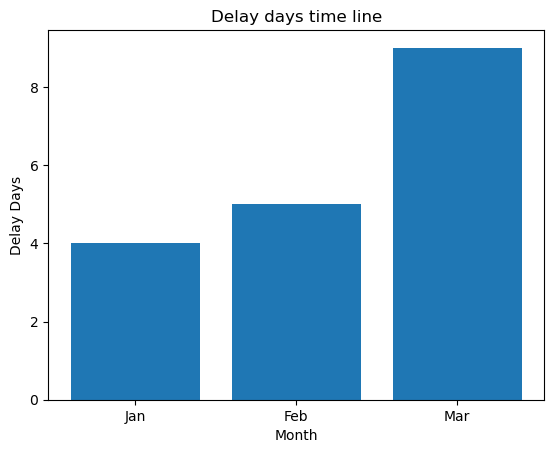

In [11]:
plt.bar(df['month'],df['delay_days'])
plt.title("Delay days time line")
plt.xlabel("Month")
plt.ylabel("Delay Days")
plt.show()

In [12]:
# save the file

cleaned_df = df.to_csv("cleaned_delivery_delay.csv", index=False)